In [2]:
#Libs

import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#Avisos
import warnings
warnings.filterwarnings('ignore')

In [9]:
#Ler
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

In [10]:
#Exibir sample
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

In [11]:
#Categorizar NPS
def nps_group(score):
    if score >= 9:
        return 'Promoter'
    elif score >= 7:
        return 'Passive'
    else:
        return 'Detractor'

In [12]:
#Aplicar a categorização
df['nps_group'] = df['nps_score'].apply(nps_group)

In [13]:
#Calcular o NPS
nps_score = ((df['nps_group'] == 'Promoter').sum() - (df['nps_group'] == 'Detractor').sum()) / len(df) * 100
print (f'NPS Score: {nps_score:.2f}%')

NPS Score: -79.96%


In [14]:
#Correlação entre nps_score e outras variáveis
correlations = df.select_dtypes(include=[np.number]).corr()['nps_score'].sort_values()
print(f'Correlations with nps_score: {correlations}%')

Correlations with nps_score: delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
customer_id                  0.015162
order_id                     0.015162
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64%


In [15]:
#Comparar as médias operacionais entre os grupos de NPS
analysis_delivery = df.groupby('nps_group')[['delivery_delay_days', 'complaints_count', 'customer_service_contacts', 'delivery_time_days']].mean()
print(analysis_delivery)

           delivery_delay_days  complaints_count  customer_service_contacts  \
nps_group                                                                     
Detractor             2.414889          4.442390                   1.632053   
Passive               1.053381          2.693950                   1.007117   
Promoter              0.718182          2.272727                   0.672727   

           delivery_time_days  
nps_group                      
Detractor            7.994310  
Passive              8.263345  
Promoter             7.936364  


In [16]:
#Média do NPS por Região do cliente
analysis_region = df.groupby('customer_region')['nps_score'].mean().sort_values()
print(analysis_region)

customer_region
Centro-Oeste    4.209829
Sudeste         4.373846
Norte           4.382609
Nordeste        4.421649
Sul             4.490979
Name: nps_score, dtype: float64


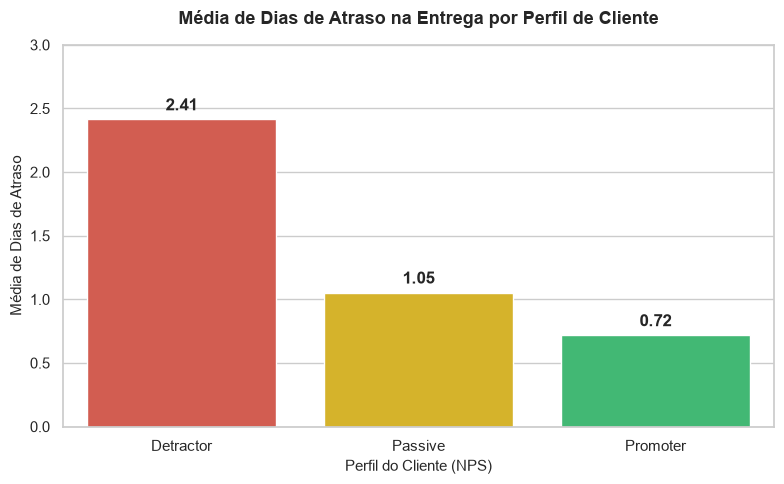

In [ ]:
#Gráfico 1: Barplot de Atraso de Entrega por Grupo NPS
delay_mean = df.groupby('nps_group')['delivery_delay_days'].mean().reindex(['Detractor', 'Passive', 'Promoter'])

#Desenhar o gráfico de barras simples
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

colors = {'Promoter': '#2ecc71', 'Passive': '#f1c40f', 'Detractor': '#e74c3c'}

ax = sns.barplot(
    x=delay_mean.index,
    y=delay_mean.values,
    palette=colors,
    hue=delay_mean.index
)

# Colocar o valor em cima das barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.05),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.title('Média de Dias de Atraso na Entrega por Perfil de Cliente', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Perfil do Cliente (NPS)', fontsize=11)
plt.ylabel('Média de Dias de Atraso', fontsize=11)
plt.ylim(0, 3) # Limita o eixo Y para dar estabilidade visual

plt.tight_layout()
plt.savefig('../reports/delivery_delay_bars.png', dpi=300)
plt.show()

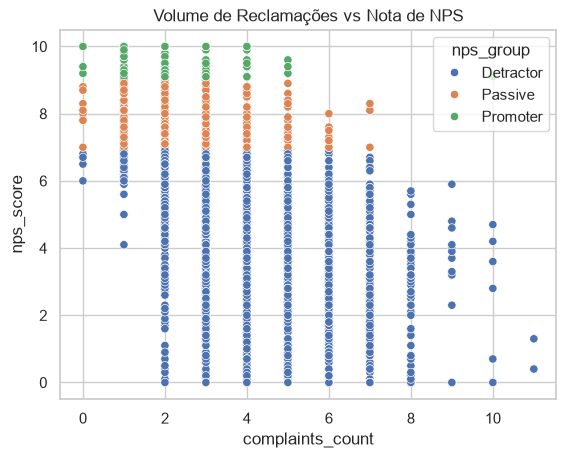

In [19]:
#Gráfico 2: Gráfico de Dispersão de Reclamações vs NPS
sns.scatterplot(x='complaints_count', y='nps_score', hue='nps_group', data=df)
plt.title('Volume de Reclamações vs Nota de NPS')
plt.savefig('../reports/complaints_vs_nps.png')
plt.show()


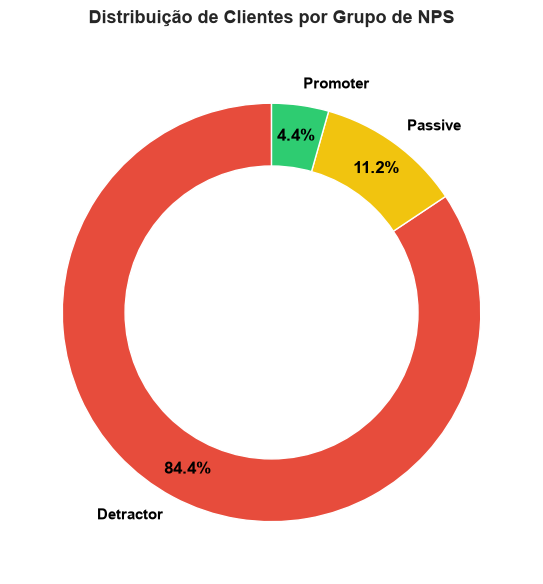

In [20]:
#Gráfico 3: Gráfico Rosca de Grupos de NPS
count = df['nps_group'].value_counts()
plt.figure(figsize=(6, 6))

#Vermelho (Detractor), Amarelo (Passive), Verde (Promote r)
colors = ['#e74c3c', '#f1c40f', '#2ecc71']

#Fatias do Gráfico
wedges, texts, autotexts = plt.pie(
    count,
    labels=count.index,
    autopct='%1.1f%%',      # Mostra a porcentagem com 1 casa decimal
    startangle=90,          # Rotaciona para começar o desenho pelo topo
    colors=colors,
    pctdistance=0.85,       # Empurra os números das porcentagens mais para a borda
    textprops=dict(color="black", weight="bold") # Deixa os textos em negrito
)

#Centro do Gráfico
central_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(central_circle)

plt.title('Distribuição de Clientes por Grupo de NPS', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/donut_nps.png', dpi=300)
plt.show()

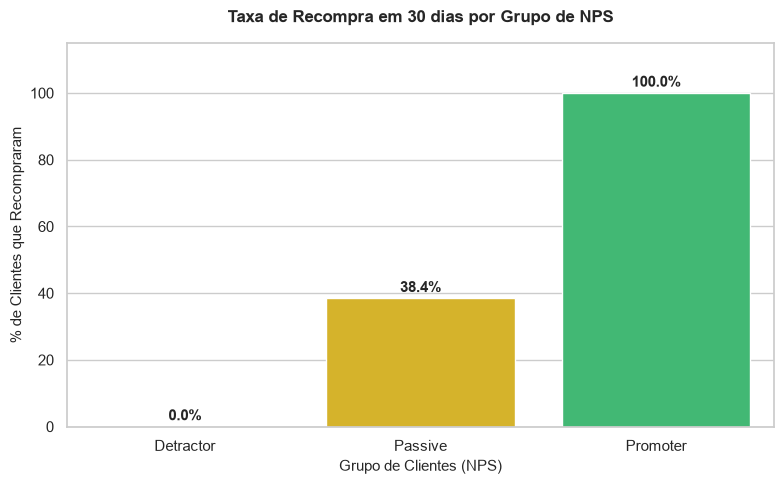

In [21]:
#Gráfico 4: Grupo de NPS que repetiram compras em 30 dias
repeat_purchase_group = df.groupby('nps_group')['repeat_purchase_30d'].mean() * 100

#Reordenar as barras
repeat_purchase_group = repeat_purchase_group.reindex(['Detractor', 'Passive', 'Promoter'])

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x=repeat_purchase_group.index,
    y=repeat_purchase_group.values,
    palette={'Promoter': '#2ecc71', 'Passive': '#f1c40f', 'Detractor': '#e74c3c'},
    hue=repeat_purchase_group.index
)

#Adicionar porcentagem nas barras
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2., p.get_height() + 1),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points',
        fontweight='bold',
        fontsize=11
    )

#Customização de títulos
plt.title('Taxa de Recompra em 30 dias por Grupo de NPS', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Grupo de Clientes (NPS)', fontsize=11)
plt.ylabel('% de Clientes que Recompraram', fontsize=11)
plt.ylim(0, 115)
plt.tight_layout()
plt.savefig('../reports/repeat_purchase.png', dpi=300)
plt.show()